In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import scipy

### $$ f(x; \nu) = \frac{1}{2^{\nu/2}\Gamma(\nu/2)} x^{\nu/2 - 1} e^{-x/2}, \; x> 0 $$

In [4]:
def chi2(x, nu):
    return 1.0/(2.0**(nu*0.5)*scipy.special.gamma(nu*0.5))*x**(nu*0.5 - 1.0)*np.exp(-x*0.5)
def var_muestral(x_array, x_mean):
    summ = 0.0 
    for element in x_array:
        summ += (element - x_mean)**2 # summ = summ + (elemnt -xmean)**2
    return summ/(np.size(x_array) - 1.0)

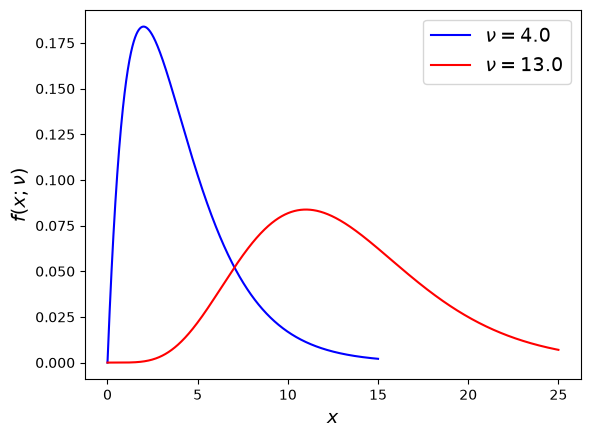

In [5]:
nu = 4
x_arr = np.linspace(0.000001, 15.0, 1000)
y_arr = chi2(x_arr, nu)

plt.plot(x_arr, y_arr, linestyle="-", color="blue", label = r"$\nu = %.1f$"%nu)

nu = 13
x_arr = np.linspace(0.000001, 25.0, 1000)
y_arr = chi2(x_arr, nu)

plt.plot(x_arr, y_arr, linestyle="-", color="red", label = r"$\nu = %.1f$"%nu)

plt.xlabel(r'$x$', fontsize=14)
plt.ylabel(r'$f(x;\nu)$', fontsize=14)
plt.legend(fontsize = 14)
plt.show()

### Chequeo de normallización 
$$
\int_0^\infty f (x; \nu) dx = 1 
$$

In [6]:
nu=4 
integral = integrate.quad(chi2, 0.000001, np.inf, args = (nu))
print('nu = %.1f, normalización = '%nu, integral[0])

nu = 4.0, normalización =  0.999999999999875


### Problema de la batería 
Ejemplo: Un fabricante de baterías para automovil garantiza que sus baterias durarán, en promedio 3 años con una desviación estándar de 1 año.
Si cinco baterías tienen duraciones de 1.9, 2.4, 3.0, 3.5, y 4.2 años, ¿El fabricante está convencido de que sus baterías dtienen su desc. estándar de 1 año ? Suponga la dist. de las baterías sigue una distribución normal 

Datos:
m=3, sigma= 1 
n= 5, v = n-1 = 4

Proc.
1.-Calcular S^2
2.-

In [7]:
n = 5 ; nu = n-1 
x_datos = np.asarray([1.9, 2.4, 3.0, 3.5, 4.2])
x_mean = np.mean(x_datos)
S2 = var_muestral(x_datos, x_mean)
print ("La varianza muestral es =", S2)

La varianza muestral es = 0.8150000000000002


In [8]:
np.var(x_datos, ddof=1)

np.float64(0.8150000000000002)

El estádistico asociado a la distribución $\xi^2$ es:
$$
\chi^2 = \frac{(n-1)S^2}{\sigma^2},
$$
que para nuestro ejemplo es:

In [9]:
sigma2 = 1.0
chi2 = (nu * S2)/sigma2
print (chi2)

3.2600000000000007


La media de la población del fabricante es 
$$
\mu = \nu = 4 
$$
y la desviación estandár de la población es
$$
\sigma = \sqrt{2/\nu} = \sqrt{8} \approx 2.82
$$


Un resultado razonable sería si el estadístico $S^2$ está "cercano" a la media de la varianza poblacional, esto es si 
$$
\chi^2 = 3.26 \in [\mu - \sigma, \mu + \sigma] = [2.82, 6.82]
$$

Entonces, como $\xi^2$ se encuentra a una $\sigma$ de distancia, podemos concluir que la varianza poblacional de un año de duración razonable.